<a href="https://colab.research.google.com/github/duangkamon214/Customer-Purchasing-Behavior-analysis/blob/main/Customer_Purchasing_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Customer Purchasing Behavior Analysis

**1. Introduction**
*   This dataset contains information about customer purchasing behavior. It has a total of 2,019,501 rows and 12 columns.
*   The purpose of this data analysis is to practice using Python and data analysis. We analyze customer purchasing behavior, such as the products with the highest number of purchases, customer repeat purchases, and the time and day when customers make purchases. This can help with decisions about product stocking, staff management, and promotions.
*   From the analysis, we found that the fresh fruits category had the highest number of items ordered. When we divided the purchase times into different time periods, we found that the afternoon was the time when the most customers made purchases. The department with the highest repeat purchase rate was dairy and eggs. The Categories with the highest repeat purchase rate was milk. The most frequent repeat purchase period was 30 days.





In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import numpy as np


In [ ]:
# Load Dataset
df = pd.read_csv("/content/ECommerce_consumer behaviour.csv.zip")

In [ ]:
# Plot Setting
sns.set( style = "whitegrid")
plt.rcParams[ "figure.figsize"] = (10,5)

**2. Data Exploration**

In [ ]:
df.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id,department,product_name
0,2425083,49125,1,2,18,NaN,17,1,0,13,pantry,baking ingredients
1,2425083,49125,1,2,18,NaN,91,2,0,16,dairy eggs,soy lactosefree
2,2425083,49125,1,2,18,NaN,36,3,0,16,dairy eggs,butter
3,2425083,49125,1,2,18,NaN,83,4,0,4,produce,fresh vegetables
4,2425083,49125,1,2,18,NaN,83,5,0,4,produce,fresh vegetables


In [ ]:
df.tail()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id,department,product_name
2019496,3390742,199430,16,3,18,5.00,83,8,0,4,produce,fresh vegetables
2019497,458285,128787,42,2,19,3.00,115,1,1,7,beverages,water seltzer sparkling water
2019498,458285,128787,42,2,19,3.00,32,2,1,4,produce,packaged produce
2019499,458285,128787,42,2,19,3.00,32,3,1,4,produce,packaged produce
2019500,458285,128787,42,2,19,3.00,123,4,1,4,produce,packaged vegetables fruits


In [ ]:
df.shape

(2019501, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019501 entries, 0 to 2019500
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   order_number            int64  
 3   order_dow               int64  
 4   order_hour_of_day       int64  
 5   days_since_prior_order  float64
 6   product_id              int64  
 7   add_to_cart_order       int64  
 8   reordered               int64  
 9   department_id           int64  
 10  department              object 
 11  product_name            object 
dtypes: float64(1), int64(9), object(2)
memory usage: 184.9+ MB


**3. Data Cleaning**

In [ ]:
# Checking Missing Values in Each Column
df.isnull().sum()

,0
order_id,0
user_id,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,124342
product_id,0
add_to_cart_order,0
reordered,0
department_id,0


The NaN values in the `days_since_prior_order` column indicate that these are the customers first orders, so there was no previous order from which to calculate the number of days.


In [ ]:
# Check for duplicate rows in the dataset.
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check for abnormal values in the data.
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id
count,2019501.00,2019501.00,2019501.00,2019501.00,2019501.00,1895159.00,2019501.00,2019501.00,2019501.00,2019501.00
mean,1707012.76,103067.27,17.15,2.74,13.44,11.39,71.21,8.36,0.59,9.93
std,985983.20,59491.17,17.53,2.09,4.24,8.97,38.21,7.15,0.49,6.28
min,10.00,2.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00
25%,852649.00,51584.00,5.00,1.00,10.00,5.00,31.00,3.00,0.00,4.00
50%,1705004.00,102690.00,11.00,3.00,13.00,8.00,83.00,6.00,1.00,9.00
75%,2559031.00,154600.00,24.00,5.00,16.00,15.00,107.00,11.00,1.00,16.00
max,3421080.00,206209.00,100.00,6.00,23.00,30.00,134.00,137.00,1.00,21.00


In [ ]:
# Check the values in each column.
df["department"].unique()

array(['pantry', 'dairy eggs', 'produce', 'canned goods', 'meat seafood',
       'frozen', 'bakery', 'beverages', 'breakfast', 'snacks',
       'international', 'household', 'personal care', 'babies', 'deli',
       'dry goods pasta', 'missing', 'alcohol', 'pets', 'bulk', 'other'],
      dtype=object)

In [ ]:
df["department_id"].unique()

array([13, 16,  4, 15, 12,  1,  3,  7, 14, 19,  6, 17, 11, 18, 20,  9, 21,
        5,  8, 10,  2])

In [ ]:
# check whether department and department_id are correctly matched.
df.groupby("department")["department_id"].unique()

,department_id
department,
alcohol,[5]
babies,[18]
bakery,[3]
beverages,[7]
breakfast,[14]
bulk,[10]
canned goods,[15]
dairy eggs,[16]
deli,[20]


In [ ]:
df[df["department"] == "missing"]["department_id"].value_counts()

,count
department_id,
21,4749


In [ ]:
# Check whether each `department_id` corresponds to only one `department`.
df.groupby("department_id")["department"].nunique()

,department
department_id,
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


*   department_id = 21 corresponds to the missing department.
*   Each `department_id` is associated with only one `department` name.




**4. Data Analysis**

4.1 Top 10 Most Ordered Categories

In [ ]:
# Exploratory data analysis (EDA)
# Top 10 Most Ordered Categories
df["product_name"].value_counts().head(10)

,count
product_name,
fresh fruits,226039
fresh vegetables,212611
packaged vegetables fruits,109596
yogurt,90751
packaged cheese,61502
milk,55150
water seltzer sparkling water,52564
chips pretzels,45306
soy lactosefree,39389


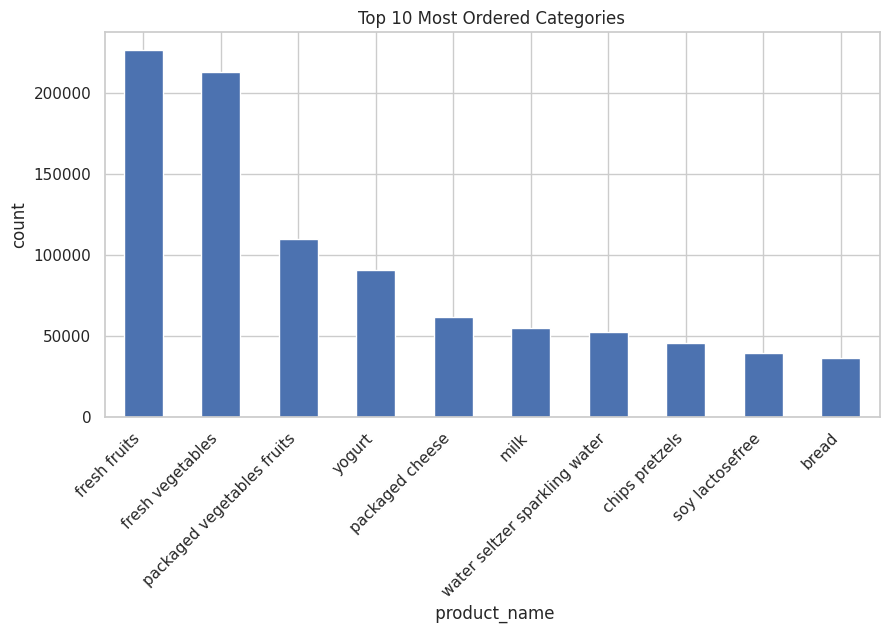

In [194]:
top_10_products = df["product_name"].value_counts().head(10)
top_10_products.plot(kind = "bar", title = "Top 10 Most Ordered Categories")
plt.xlabel(" product_name")
plt.xticks(rotation = 45, ha = "right")
plt.ylabel("count")
plt.show()

4.2.1 Count purchases by order day (order_dow)

In [ ]:
# Count purchases by order day (order_dow)
purchases = df["order_dow"].value_counts().sort_index()
purchases

,count
order_dow,
0,391831
1,349236
2,261912
3,238730
4,234884
5,262157
6,280751


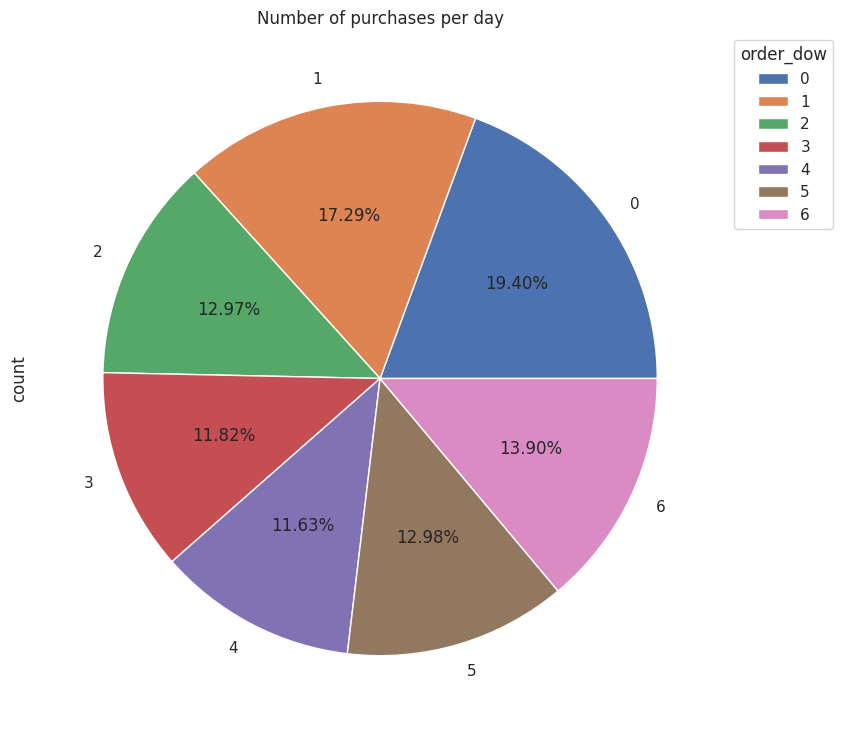

In [ ]:
purchases.plot( kind = "pie",autopct = "%1.2f%%", title = "Number of purchases per day", figsize = (9,9)  )
plt.legend(title = "order_dow", bbox_to_anchor = (1 , 1))

The dataset documentation does not indicate which weekday order_dow = 0 corresponds to, so days are shown as numbers 0–6.

4.2.2 The time period during which customers place an order.



In [ ]:
df["order_hour_of_day"].value_counts().sort_index()

,count
order_hour_of_day,
0,13481
1,7283
2,4210
3,2994
4,3269
5,5732
6,18293
7,54143
8,106754


In [ ]:
pd.cut(df["order_hour_of_day"], bins = [-1, 5, 11, 17, 23] ).value_counts().sort_index()

,count
order_hour_of_day,
"(-1, 5]",36969
"(5, 11]",673035
"(11, 17]",952505
"(17, 23]",356992


In [195]:
# Categorize product orders by time period.
def order_time(t):
  if t in [-1, 0, 1, 2, 3, 4, 5]:
    return "Night"
  elif t in [6, 7, 8, 9, 10, 11]:
    return "Morning"
  elif t in [12, 13, 14, 15, 16, 17]:
    return "Afternoon"
  elif t in [18, 19, 20, 21, 22, 23]:
    return "Evening"
  else:
    return t

In [196]:
df["order_time_list"] = df["order_hour_of_day"].apply(order_time)
df.head()


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id,department,product_name,order_time_list
0,2425083,49125,1,2,18,NaN,17,1,0,13,pantry,baking ingredients,Evening
1,2425083,49125,1,2,18,NaN,91,2,0,16,dairy eggs,soy lactosefree,Evening
2,2425083,49125,1,2,18,NaN,36,3,0,16,dairy eggs,butter,Evening
3,2425083,49125,1,2,18,NaN,83,4,0,4,produce,fresh vegetables,Evening
4,2425083,49125,1,2,18,NaN,83,5,0,4,produce,fresh vegetables,Evening


In [197]:
# Create a table showing the time periods when customers make purchases.
df["order_time_list"] = pd.Categorical( df["order_time_list"], categories = ["Morning", "Afternoon", "Evening", "Night"], ordered = True)
pivot_time = pd.pivot_table( df, index = "order_dow", columns = "order_time_list", values = "user_id", aggfunc = "nunique", observed = False )
pivot_time

order_time_list,Morning,Afternoon,Evening,Night
order_dow,,,,
0,9861,15800,5700,622
1,10913,14321,5335,533
2,8338,11737,4869,492
3,7810,11151,4519,435
4,7535,10627,4711,462
5,8261,11377,4407,516
6,7738,11580,4494,508


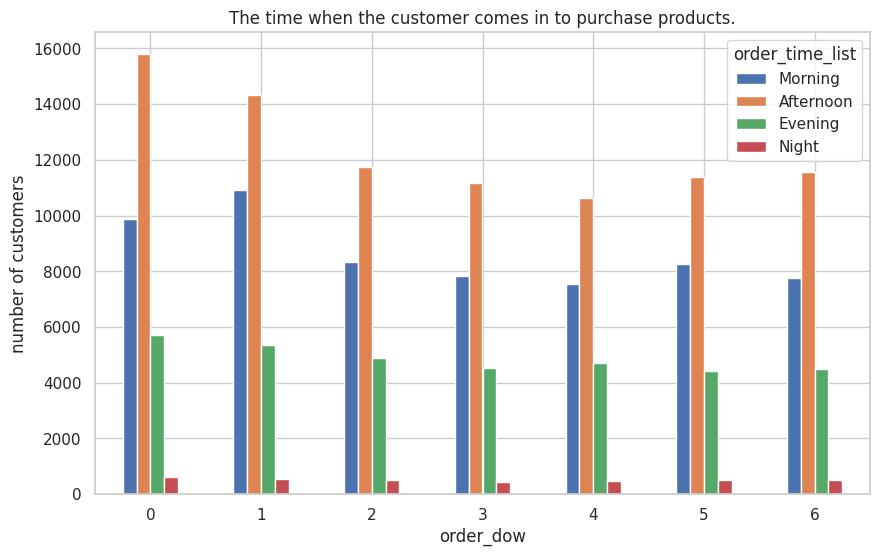

In [198]:
pivot_time.plot( kind = "bar", title = "The time when the customer comes in to purchase products.", figsize = (10,6))
plt.xlabel("order_dow")
plt.xticks(rotation = 0)
plt.ylabel('number of customers')
plt.show()

**4.3 Repeat purchase behavior**




4.3.1 The department with the highest rate of repeat customers.

In [ ]:
total_count= df.groupby("department")["reordered"].count()
total_count

,reordered
department,
alcohol,9439
babies,25940
bakery,72983
beverages,168126
breakfast,44605
bulk,2133
canned goods,66053
dairy eggs,336915
deli,65176


In [ ]:
df["reordered"].unique()

array([0, 1])

In [ ]:
repeat = df[df["reordered"] == 1]
repeat_count = repeat.groupby("department")["reordered"].count()
repeat_count

,reordered
department,
alcohol,5264
babies,15069
bakery,45969
beverages,110117
breakfast,25046
bulk,1230
canned goods,30264
dairy eggs,225798
deli,39917


In [ ]:
repeat_count.head()

,reordered
department,
alcohol,5264
babies,15069
bakery,45969
beverages,110117
breakfast,25046


In [ ]:
reorder_rate = repeat_count / total_count
reorder_rate.sort_values( ascending = False)

,reordered
department,
dairy eggs,0.67
beverages,0.65
produce,0.65
bakery,0.63
deli,0.61
pets,0.60
babies,0.58
bulk,0.58
snacks,0.57


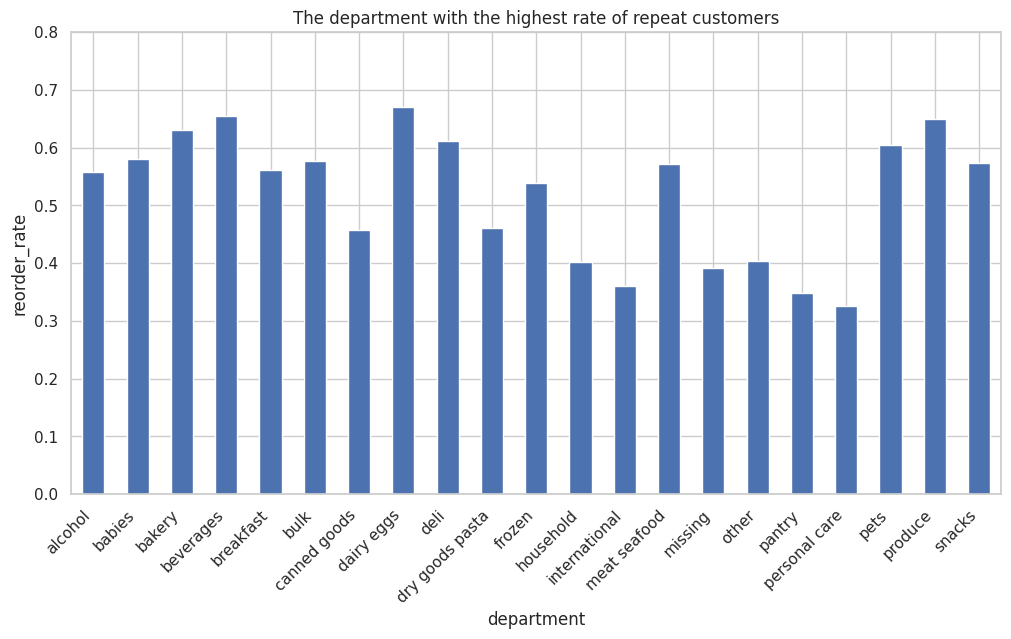

In [ ]:
reorder_rate.plot(kind = "bar", title = "The department with the highest rate of repeat customers", figsize = (12,6))
plt.xlabel("department")
plt.xticks(rotation = 45, ha = "right")
plt.yticks(np.arange(0, 0.9, 0.1))
plt.ylabel("reorder_rate")
plt.show()

The dairy eggs department has the highest reorder rate

4.3.2 10 Categories with the Highest Repurchase Rates

In [ ]:
total_prod = df.groupby("product_name")["reordered"].count()
total_prod

,reordered
product_name,
air fresheners candles,1258
asian foods,10426
baby accessories,504
baby bath body care,515
baby food formula,23355
...,...
trash bags liners,2020
vitamins supplements,2912
water seltzer sparkling water,52564


In [ ]:
repeat_prod = df[df["reordered"] == 1]
repeat_prod_count = repeat_prod.groupby("product_name")["reordered"].count()
repeat_prod_count

,reordered
product_name,
air fresheners candles,365
asian foods,3561
baby accessories,260
baby bath body care,143
baby food formula,13847
...,...
trash bags liners,697
vitamins supplements,939
water seltzer sparkling water,38467


In [ ]:
repeat_pur_rate = repeat_prod_count / total_prod
repeat_pur_rate.sort_values( ascending = False).head(10)

,reordered
product_name,
milk,0.78
water seltzer sparkling water,0.73
fresh fruits,0.72
eggs,0.71
soy lactosefree,0.69
packaged produce,0.69
cream,0.69
yogurt,0.69
bread,0.67


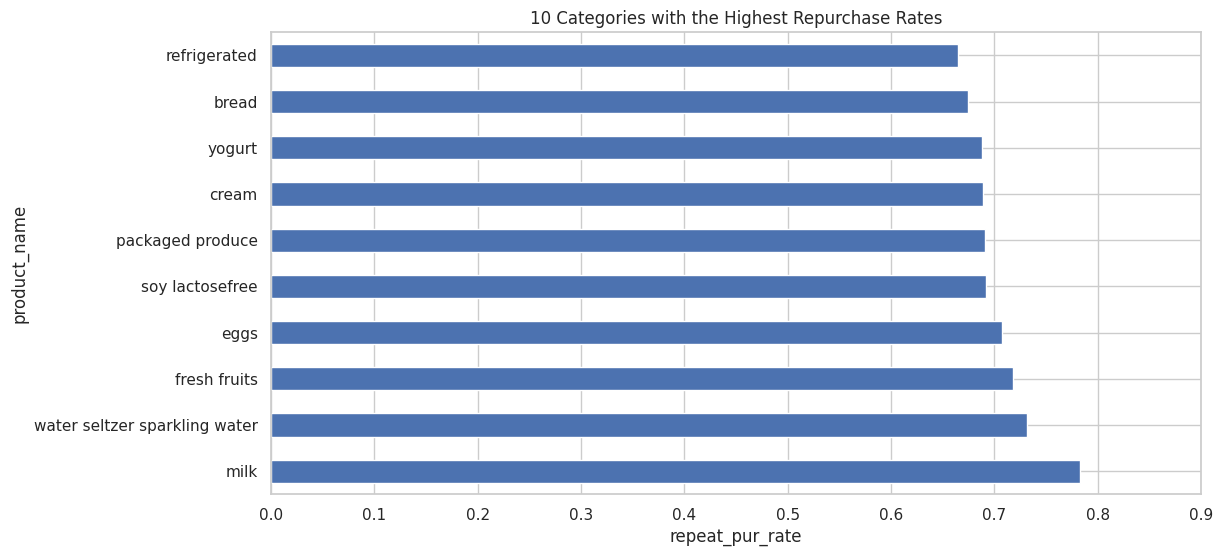

In [199]:
repeat_pur_rate.sort_values(ascending = False ).head(10).plot(kind = "barh", title = "10 Categories with the Highest Repurchase Rates", figsize = (12,6))
plt.xlabel("repeat_pur_rate")
plt.xticks(np.arange(0,1.0,0.1))
plt.ylabel("product_name")
plt.show()

The Categories with the highest rate of customer repeat purchases is milk.

4.4 Repeat purchase frequency

In [ ]:
orders = df.drop_duplicates("order_id") # One order per row.
repeat_pur_freq = orders["days_since_prior_order"].value_counts().sort_index().sort_values( ascending = False)
repeat_pur_freq

,count
days_since_prior_order,
30.00,20982
7.00,18882
6.00,14262
4.00,13054
3.00,12673
5.00,12508
2.00,11362
8.00,10466
1.00,8756


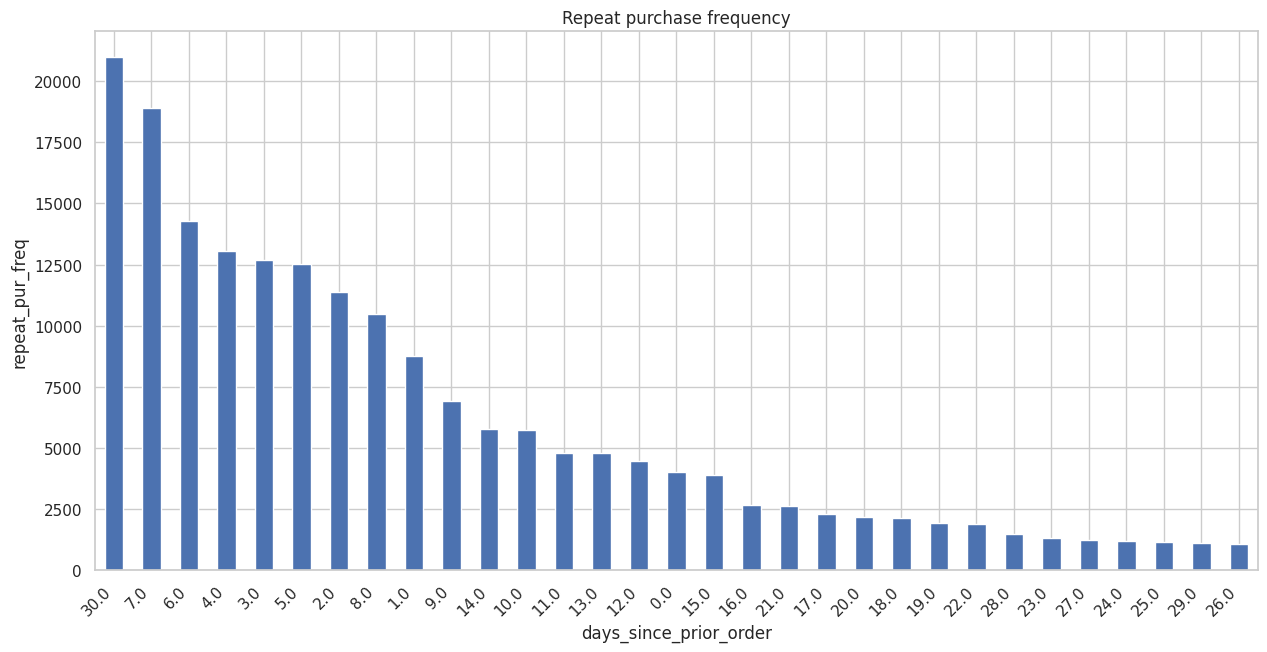

In [193]:
repeat_pur_freq.plot( kind = "bar", title = "Repeat purchase frequency", figsize = (15,7))
plt.xlabel("days_since_prior_order")
plt.xticks(np.arange(0, 30.1, 1.0), rotation = 45, ha = "right" )
plt.ylabel("repeat_pur_freq")
plt.show()

Most repeat purchases occur after 30 days, followed by 7 and 6 days.

note: The maximum value is 30, so this group likely includes gaps of 30 days or more.

**Key insights**
* The fresh fruits category had the highest number of items ordered.
* Most customers bought products on Day 0, followed by Day 1, while Day 4 had the lowest number of purchases.
* The afternoon was the time when the most customers made purchases.
* Dairy and eggs had the highest repeat purchase rate.
* Milk had the highest repeat purchase rate.
* The most common time for customers to make a repeat purchase was 30 days.
---
**Recommendations**
* Plan the stock to be enough for customer demand.
* The afternoon is the time when many customers come to buy products. During this time, more staff may be needed to provide faster service.
* We found that the most common time for customers to come back and buy again is 30 days. We can use this information to plan stock orders and promotions.
---
**Conclusion**
* From the data analysis, we learned about customer purchasing behavior. We can use this information to help manage product stock and services to meet customer needs.









